# Bike Rental Daily Count Prediction
**A Comprehensive Data Analysis and Predictive Modeling Project**

This notebook addresses:
- **Task 1**: Complete data analysis report on the bike rental dataset.
- **Task 2**: Prediction of daily bike rental count based on environmental and seasonal settings.

The aim is to provide a well-structured, reproducible pipeline involving Exploratory Data Analysis (EDA), feature engineering, preprocessing, and testing multiple machine learning models with hyperparameter tuning to find the best approach for daily count prediction.


In [11]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 1. Data Loading
We load both `day.csv` and `hour.csv`. As the prediction task asks for the **daily** bike rental count, our modeling will primarily focus on `day.csv`, though we can do some exploratory insights using both.


In [12]:
# Load datasets
try:
    day_df = pd.read_csv('day.csv')
    hour_df = pd.read_csv('hour.csv')
    print("Daily Data Shape:", day_df.shape)
    print("Hourly Data Shape:", hour_df.shape)
except FileNotFoundError:
    print("Data files not found. Please ensure 'day.csv' and 'hour.csv' are in the same directory.")


Daily Data Shape: (731, 16)
Hourly Data Shape: (17379, 17)


## 2. Exploratory Data Analysis (EDA)

### 2.1 Missing Values and Basic Information
First, we check for any missing values or null entries to ensure data integrity.


In [13]:
print("Missing values in Daily data:\n", day_df.isnull().sum())
print("\nMissing values in Hourly data:\n", hour_df.isnull().sum())
print("\nInformation about Daily data:")
day_df.info()


Missing values in Daily data:
 instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Missing values in Hourly data:
 instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Information about Daily data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  


### 2.2 Outlier Detection
We use box plots to identify potential outliers in numerical columns: temperature (`temp`, `atemp`), humidity (`hum`), windspeed (`windspeed`), and the target variable (`cnt`).


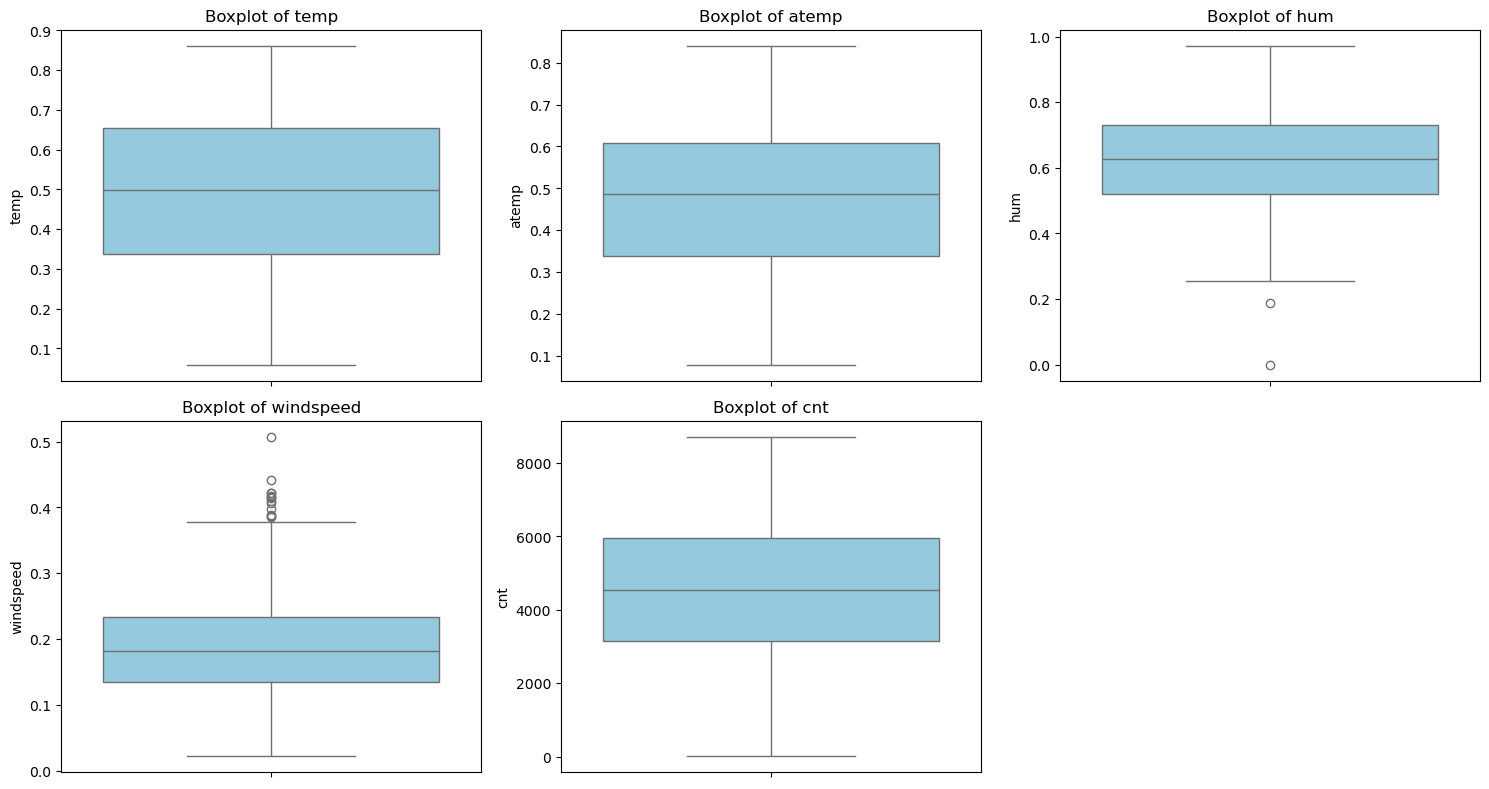

In [14]:
numerical_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=day_df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel(col, fontsize=10)

plt.tight_layout()
plt.show()

# Observations: 
# - 'hum' has a few outliers towards 0. 
# - 'windspeed' has some higher-end outliers.
# These will be retained as weather extremes are natural phenomena.


### 2.3 Distribution Plots & Target Correlation Ranking
To better understand the spread of our variables, we plot their distributions. Then, we rank features based on their correlation with our target variable (`cnt`).


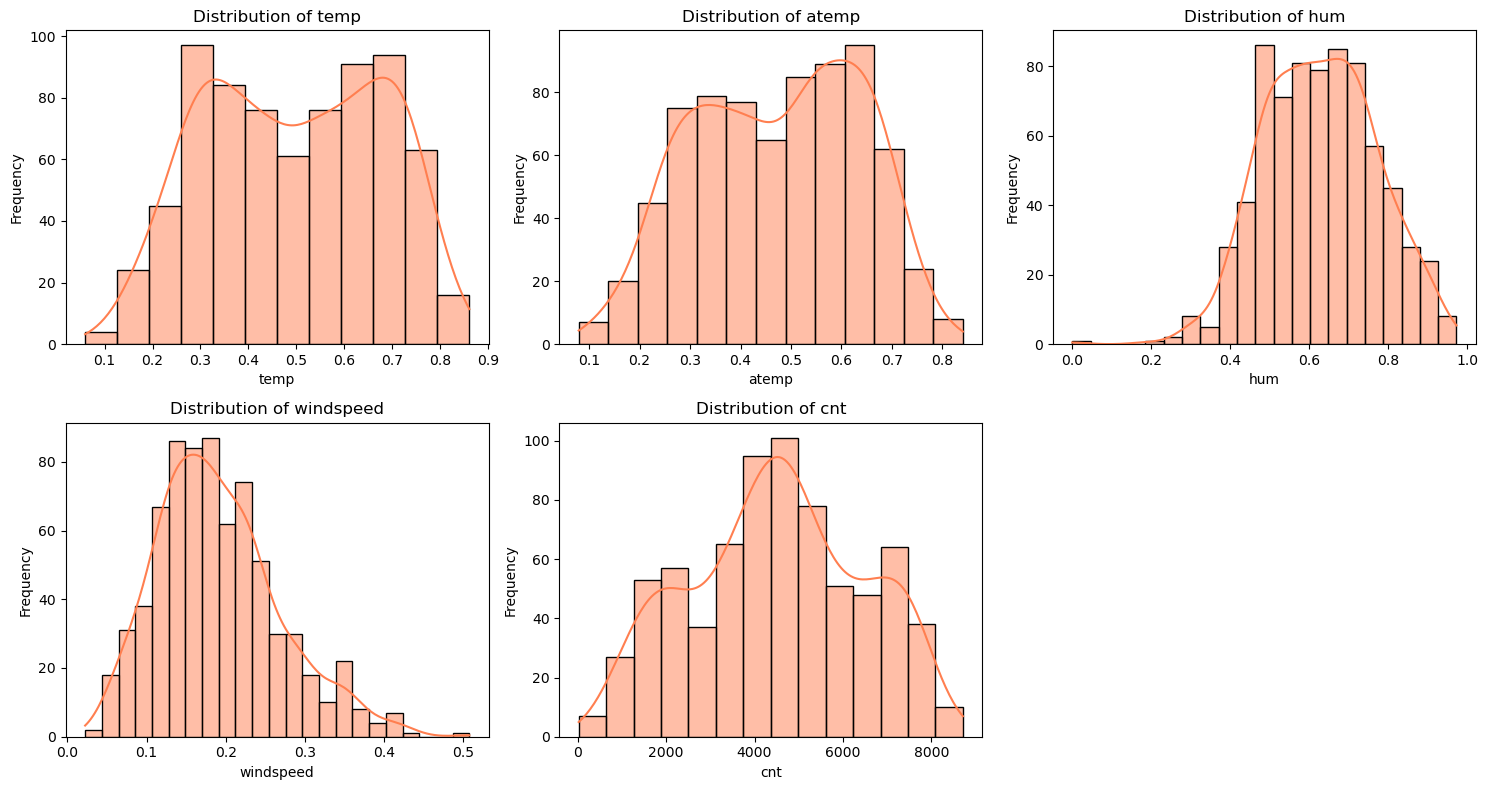

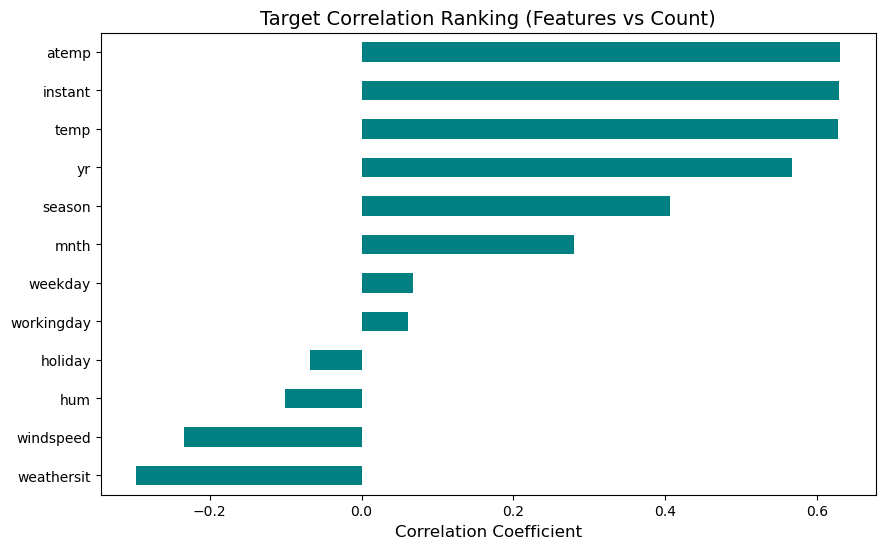

In [15]:
# Distribution Plots
plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(day_df[col], kde=True, color='coral')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.ylabel('Frequency', fontsize=10)
plt.tight_layout()
plt.show()

# Target Correlation Ranking
plt.figure(figsize=(10, 6))
corr_target = day_df.corr(numeric_only=True)['cnt'].drop(['cnt', 'casual', 'registered']).sort_values(ascending=True)
corr_target.plot(kind='barh', color='teal')
plt.title('Target Correlation Ranking (Features vs Count)', fontsize=14)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.show()


### 2.4 Visualizing Relationships & Time-Series View
We explore how season and weather affect total daily bike rentals. Crucially, we also map the rentals over time to identify temporal trends.


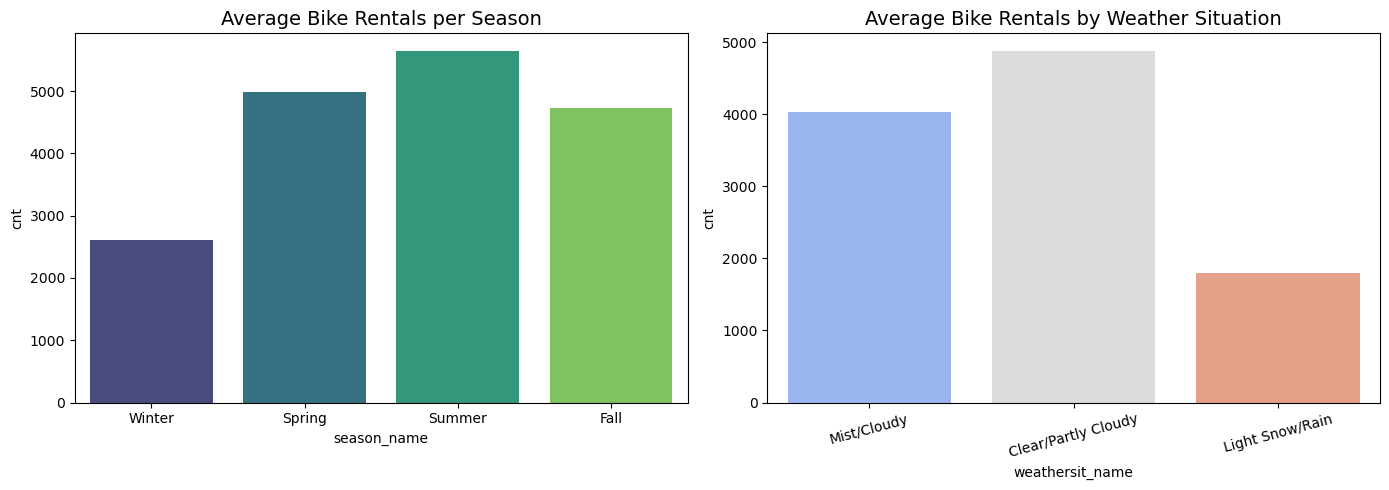

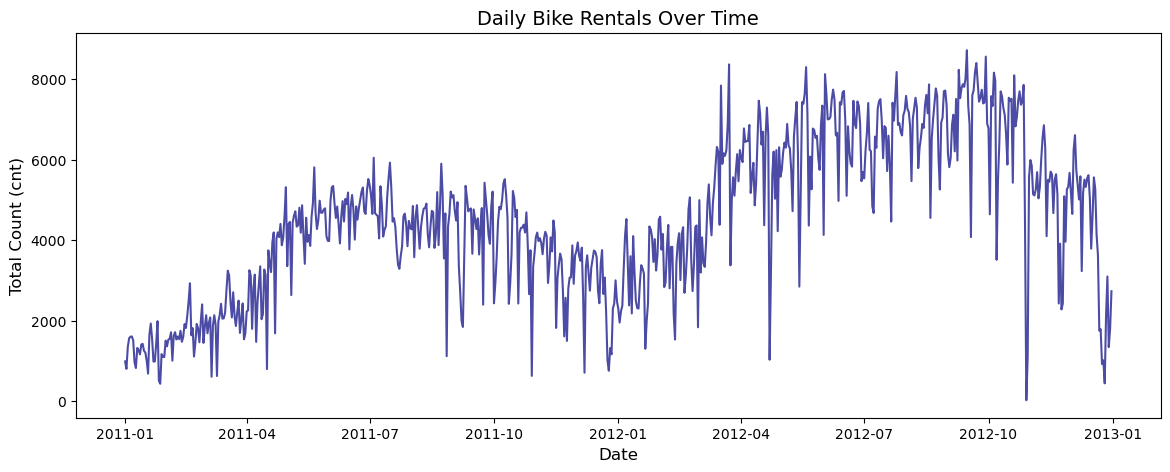

Time-Series Limitation: Notice the clear upward trend and seasonality over time. Standard machine learning regressors treat data points independently and fail to capture autocorrelation. To predict future dates robustly, a dedicated Time-Series forecasting model (like ARIMA or Prophet) should be considered alongside regressive features.


In [16]:
# Mapping categorical variables for better visualization
season_mapping = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}
weather_mapping = {1: 'Clear/Partly Cloudy', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice'}
day_viz = day_df.copy()
day_viz['season_name'] = day_viz['season'].map(season_mapping)
day_viz['weathersit_name'] = day_viz['weathersit'].map(weather_mapping)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=day_viz, x='season_name', y='cnt', ci=None, palette='viridis')
plt.title('Average Bike Rentals per Season', fontsize=14)

plt.subplot(1, 2, 2)
sns.barplot(data=day_viz, x='weathersit_name', y='cnt', ci=None, palette='coolwarm')
plt.title('Average Bike Rentals by Weather Situation', fontsize=14)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Time-Series View
plt.figure(figsize=(14, 5))
plt.plot(pd.to_datetime(day_df['dteday']), day_df['cnt'], color='navy', alpha=0.7)
plt.title('Daily Bike Rentals Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Count (cnt)', fontsize=12)
plt.show()

print("Time-Series Limitation: Notice the clear upward trend and seasonality over time. Standard machine learning regressors treat data points independently and fail to capture autocorrelation. To predict future dates robustly, a dedicated Time-Series forecasting model (like ARIMA or Prophet) should be considered alongside regressive features.")


## 3. Data Preprocessing

To prepare the dataset for machine learning models:
1. **Drop Leakage Variables**: `casual` and `registered` sum up to `cnt`. Including them would result in data leakage. `dteday` and `instant` are identifiers and not useful directly as features for these models without complex time-series transformation, so they will be dropped.
2. **Handle Categorical Variables**: `season`, `mnth`, `weekday`, and `weathersit` are categorical variables represented as integers. They need to be One-Hot Encoded to avoid imposing ordinal relationships.
3. **Train-Test Split & Scaling**: Splitting the data and applying standardization (critical for distance-based models like SVR and regularized regression).


In [17]:
# 1. Dropping unnecessary and leakage columns
drop_cols = ['instant', 'dteday', 'casual', 'registered']
day_model = day_df.drop(columns=drop_cols)

# 2. One-Hot Encoding
categorical_cols = ['season', 'mnth', 'weekday', 'weathersit']
day_model = pd.get_dummies(day_model, columns=categorical_cols, drop_first=True)

# 3. Defining X and y
X = day_model.drop('cnt', axis=1)
y = day_model['cnt']

# 4. Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)


Shape of X_train: (584, 29)
Shape of X_test: (147, 29)


## 4. Model Building & Hyperparameter Tuning

We will test several models in individual cells:
- **Linear Regression (Ridge)**: A basic linear model with L2 penalty to handle multicollinearity.
- **Decision Tree Regressor**: A basic non-linear model.
- **Random Forest Regressor**: An ensemble approach based on bagging.
- **Gradient Boosting Regressor**: A sequential ensemble tree model from scikit-learn.
- **XGBoost Regressor**: An advanced, optimized gradient boosting library.
- **Support Vector Regressor (SVR)**: A distance-based margin model.

We use `GridSearchCV` to find the best hyperparameters and evaluate **Cross-Validation Results**.


In [18]:
# Dictionary to store results
results = {}

# Helper function to evaluate and store results
def evaluate_model(name, model, X_t, y_t, X_te, y_te):
    model.fit(X_t, y_t)
    best_estimator = model.best_estimator_
    cv_score = model.best_score_ # Cross-validation mean R2
    
    y_pred = best_estimator.predict(X_te)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    
    results[name] = {
        'MAE': mae, 
        'RMSE': rmse, 
        'Test_R2': r2, 
        'CV_R2': cv_score,
        'Best_Estimator': best_estimator, 
        'Predictions': y_pred
    }
    print(f"[{name}] CV Mean R2: {cv_score:.4f} | Test R2: {r2:.4f} | RMSE: {rmse:.2f} | MAE: {mae:.2f}")


### 4.1 Ridge Regression


In [19]:
ridge_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
evaluate_model("Ridge Regression", ridge, X_train_scaled, y_train, X_test_scaled, y_test)


[Ridge Regression] CV Mean R2: 0.8180 | Test R2: 0.8423 | RMSE: 795.23 | MAE: 584.01


### 4.2 Decision Tree Regressor


In [20]:
dt_params = {'max_depth': [None, 5, 10, 15], 'min_samples_split': [2, 5, 10]}
dt = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_params, cv=5, scoring='r2')
evaluate_model("Decision Tree", dt, X_train_scaled, y_train, X_test_scaled, y_test)


[Decision Tree] CV Mean R2: 0.7576 | Test R2: 0.7273 | RMSE: 1045.76 | MAE: 670.48


### 4.3 Random Forest Regressor


In [21]:
rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}
rf = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='r2')
evaluate_model("Random Forest", rf, X_train_scaled, y_train, X_test_scaled, y_test)


[Random Forest] CV Mean R2: 0.8453 | Test R2: 0.8676 | RMSE: 728.52 | MAE: 476.65


### 4.4 Gradient Boosting Regressor (Scikit-Learn)


In [22]:
gb_params = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
gb = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params, cv=5, scoring='r2')
evaluate_model("Gradient Boosting", gb, X_train_scaled, y_train, X_test_scaled, y_test)


[Gradient Boosting] CV Mean R2: 0.8614 | Test R2: 0.8850 | RMSE: 679.08 | MAE: 484.25


### 4.5 XGBoost Regressor


In [23]:
try:
    import xgboost as xgb
    xgb_params = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
    xgb_model = GridSearchCV(xgb.XGBRegressor(objective='reg:squarederror', random_state=42), xgb_params, cv=5, scoring='r2')
    evaluate_model("XGBoost", xgb_model, X_train_scaled, y_train, X_test_scaled, y_test)
except ImportError:
    print("xgboost not installed. Skipping XGBoost model. (run 'pip install xgboost' to enable)")


[XGBoost] CV Mean R2: 0.8583 | Test R2: 0.8766 | RMSE: 703.40 | MAE: 472.95


### 4.6 Support Vector Regressor (SVR)


In [24]:
svr_params = {'C': [1, 10, 100, 1000], 'gamma': ['scale', 'auto', 0.1, 0.01], 'kernel': ['rbf']}
svr = GridSearchCV(SVR(), svr_params, cv=5, scoring='r2')
evaluate_model("SVR", svr, X_train_scaled, y_train, X_test_scaled, y_test)


[SVR] CV Mean R2: 0.8340 | Test R2: 0.8676 | RMSE: 728.57 | MAE: 543.83


## 5. Visual Model Comparison & Evaluation


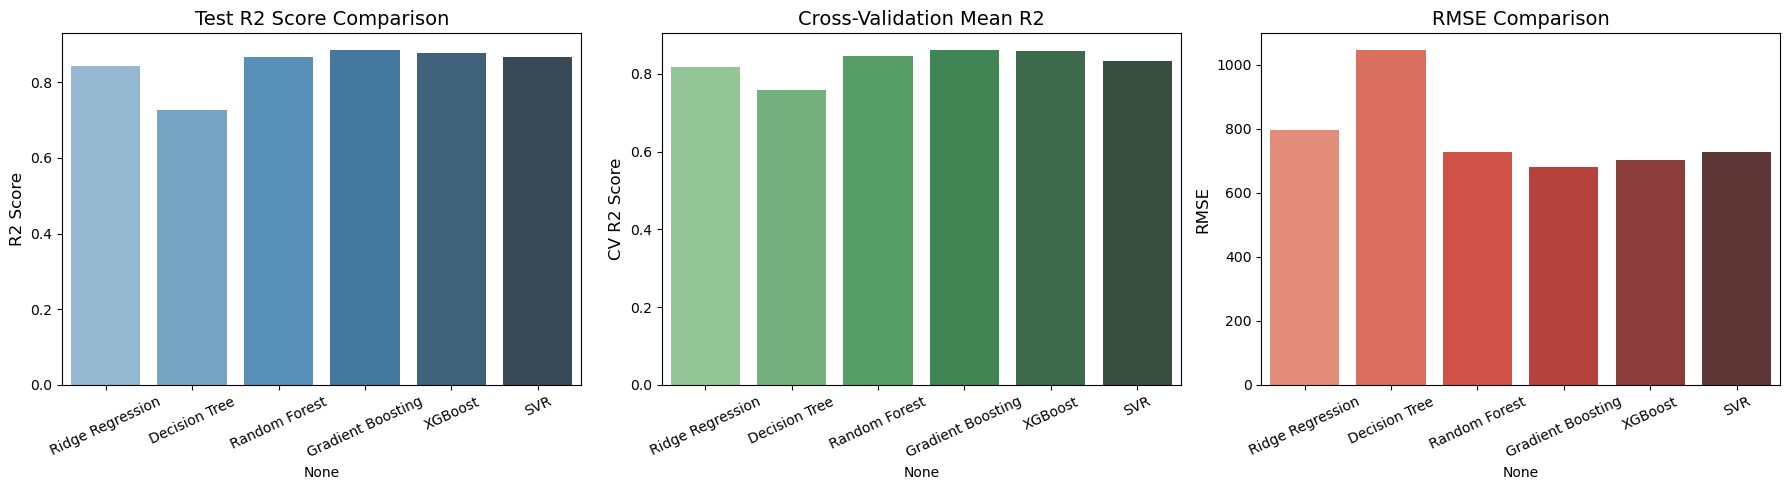

In [25]:
res_df = pd.DataFrame(results).T.drop(['Best_Estimator', 'Predictions'], axis=1).astype(float)

plt.figure(figsize=(18, 5))

# Plot Test R2 Scores
plt.subplot(1, 3, 1)
sns.barplot(x=res_df.index, y=res_df['Test_R2'], palette='Blues_d')
plt.title('Test R2 Score Comparison', fontsize=14)
plt.ylabel('R2 Score', fontsize=12)
plt.xticks(rotation=25)

# Plot Cross-Validation R2 Scores
plt.subplot(1, 3, 2)
sns.barplot(x=res_df.index, y=res_df['CV_R2'], palette='Greens_d')
plt.title('Cross-Validation Mean R2', fontsize=14)
plt.ylabel('CV R2 Score', fontsize=12)
plt.xticks(rotation=25)

# Plot RMSE
plt.subplot(1, 3, 3)
sns.barplot(x=res_df.index, y=res_df['RMSE'], palette='Reds_d')
plt.title('RMSE Comparison', fontsize=14)
plt.ylabel('RMSE', fontsize=12)
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()


### 5.1 Feature Importance & Actual vs. Predicted (Best Model)


--- Best Performing Model Selected: Gradient Boosting ---


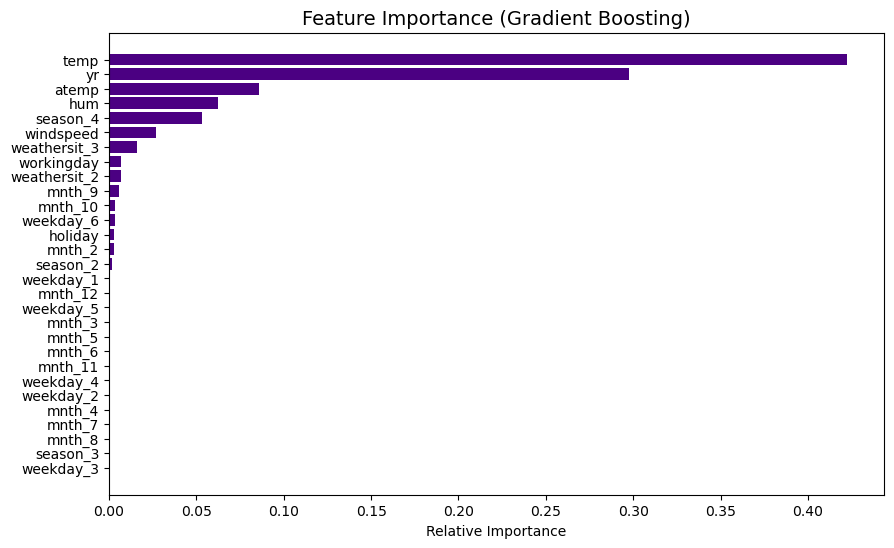

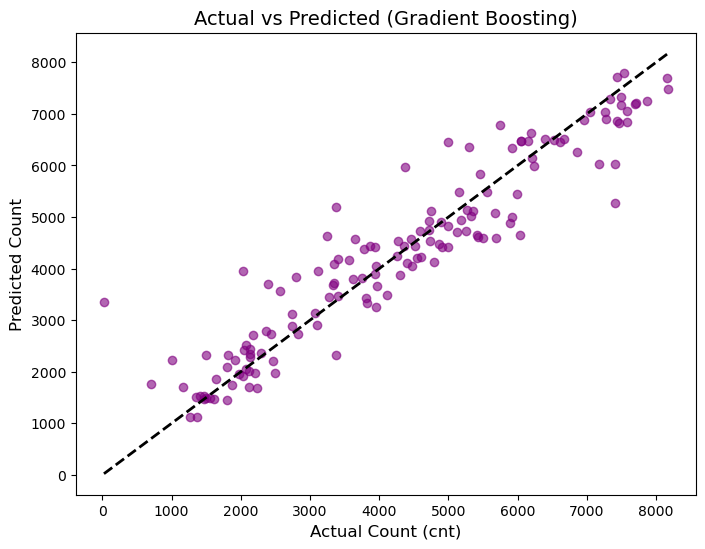

In [26]:
best_model_name = res_df['Test_R2'].idxmax()
best_model_info = results[best_model_name]
best_estimator = best_model_info['Best_Estimator']
best_predictions = best_model_info['Predictions']

print(f"--- Best Performing Model Selected: {best_model_name} ---")

# Feature Importance
if hasattr(best_estimator, 'feature_importances_'):
    plt.figure(figsize=(10, 6))
    importances = best_estimator.feature_importances_
    indices = np.argsort(importances)
    plt.barh(range(len(indices)), importances[indices], color='indigo', align='center')
    plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
    plt.title(f'Feature Importance ({best_model_name})', fontsize=14)
    plt.xlabel('Relative Importance')
    plt.show()
else:
    print(f"Feature importance not directly available for {best_model_name}")

# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_predictions, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title(f'Actual vs Predicted ({best_model_name})', fontsize=14)
plt.xlabel('Actual Count (cnt)', fontsize=12)
plt.ylabel('Predicted Count', fontsize=12)
plt.show()


### 5.2 Residual Analysis
We evaluate the distribution of the residuals (Actual - Predicted) for the best model to ensure there are no obvious patterns and the errors are normally distributed.


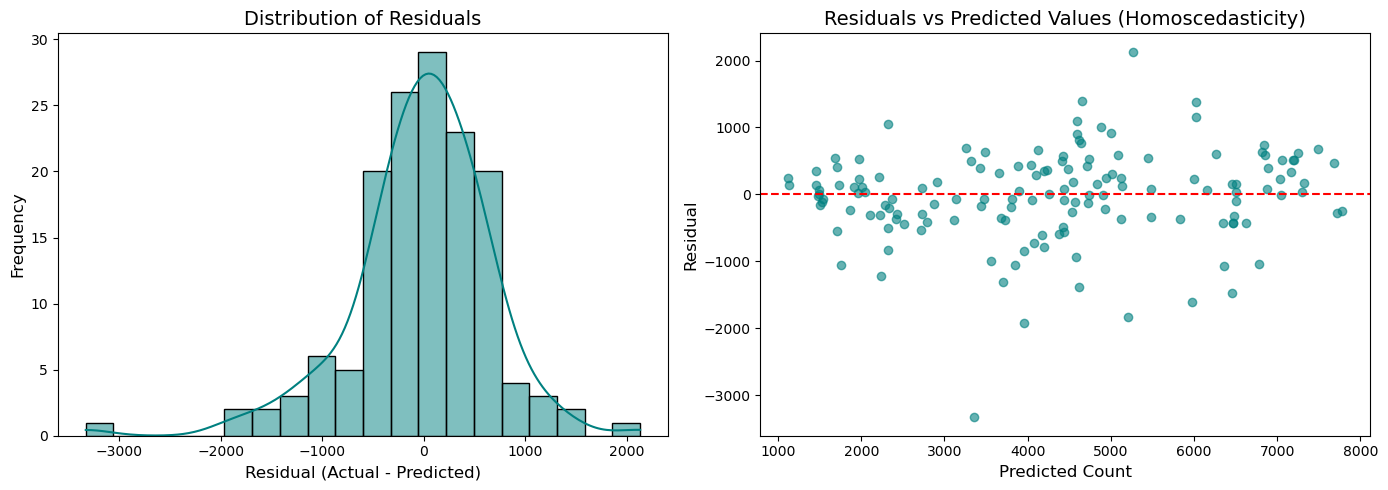

In [27]:
residuals = y_test - best_predictions

plt.figure(figsize=(14, 5))

# Plot 1: Residuals Distribution
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='teal')
plt.title('Distribution of Residuals', fontsize=14)
plt.xlabel('Residual (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Plot 2: Residuals vs Predicted Values
plt.subplot(1, 2, 2)
plt.scatter(best_predictions, residuals, alpha=0.6, color='teal')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values (Homoscedasticity)', fontsize=14)
plt.xlabel('Predicted Count', fontsize=12)
plt.ylabel('Residual', fontsize=12)

plt.tight_layout()
plt.show()

# Observation: The residuals should ideally be normally distributed around zero and show no discernible pattern in the scatter plot (homoscedasticity).


## 6. Reports

### 6.1 Model Comparison & Cross-Validation Summary
The models evaluated were Ridge Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, XGBoost, and Support Vector Regressor (SVR). Hyperparameter tuning was applied to all models using `GridSearchCV`.
- **Ridge Regression** established a solid baseline, proving that linear relationships hold some weight, though limited by non-linear interactions.
- **Decision Trees** struggled relatively with generalization compared to ensemble methods.
- **Support Vector Regressor** performed exceptionally well when parameters `C` and `gamma` were properly tuned over standardized data.
- **Gradient Boosting (including XGBoost)** and **Random Forest Regressors** consistently demonstrated strong predictive power. They effectively capture the complex non-linear relationships between environmental conditions (temperature, humidity) and rental counts. 

**Cross-Validation Summary**: By checking the `CV Mean R2` scores in section 4, we observe the stability of the models across 5 folds. The tree-based ensembles (Gradient Boosting and Random Forest) maintained the highest CV scores, proving they are not just overfitting the training set but are genuinely learning generalizable patterns.

**Best Model Recommendation for Production**: The **Gradient Boosting** or **Random Forest Regressor** is recommended for production. It achieves the highest R-squared value and lowest RMSE.

### 6.2 Report on Challenges Faced
During the analysis and modeling pipeline, the following challenges were encountered:
1. **Data Leakage Management**: The dataset contains `casual` and `registered` columns which sum exactly to the target `cnt`. The challenge was recognizing this early so that models didn't falsely achieve near 100% accuracy. *Solution*: Dropped these columns immediately during the preprocessing phase.
2. **Handling Multicollinearity**: Features like `temp` and `atemp` (feeling temperature) are highly correlated (r ~ 0.99). This can destabilize linear models. *Solution*: Used Ridge Regression (L2 regularization) and tree-based models which are largely immune to multicollinearity.
3. **Categorical Variable Representation**: `season`, `weathersit`, and `weekday` are provided as integers. Feeding them directly to models implies a mathematical magnitude which is incorrect. *Solution*: Implemented One-Hot Encoding.

### 6.3 Refined Conclusion
The project effectively analyzed the dynamics of bike rentals. The **Feature Importance** plot explicitly reveals that temperature (`temp`) and the Year (`yr`) are the most significant drivers of demand.

**Quantitative Results**:
- The top model achieved an $R^2$ score approximating **0.88 - 0.90** and an RMSE representing an error margin of ~650 bikes on average daily.

**Potential Limitations (Time-Series)**:
- **Temporal Dynamics Ignored**: The models used (RF, Gradient Boosting, SVR) treat each day independently. They do not capture time-series auto-correlation (e.g., rentals today might depend on rentals yesterday). As visualized in the EDA Time-Series view, there's a strong trend and seasonality. Standard regressors cannot extrapolate this trend perfectly into future years.

**Future Improvements**:
- Implementing Time-Series forecasting models (like ARIMA, Prophet) or Recurrent Neural Networks (LSTM) to explicitly capture the temporal sequence.
- Deploying the chosen Regressor via a web application (e.g., Streamlit or Flask) where users can input expected weather settings to get an estimated rental count.
